# Crime Data Analysis Notebook

## Overview
This notebook performs data analysis on street crime data across 4 police forces: Metropolitan, West Yorkshire, Devon & Cornwall and North Yorkshire, from January 2024 to December 2025.
All data cleaning and preprocessing was completed in the preprocessing notebook.The cleaned dataset is loaded here ready for analysis.
The analysis aims to identify crime trends, distributions and regional differences to support Nadine Green (Head of Sales) in making informed real estate decisions. There was a particular focus on the rural vs urban divide and how different crime types vary between police forces over time.

1. Total Crime Overview
2. Crime Type Distribution
   - 2.1 Crime Type Distribution - Regional
3. Crime Rate per 100,000 Population
4. Time Series Analysis
5. Crime Rate vs Median House Price Prices
6. Crime Outcomes by Force
7. Crime Density Maps - Overview
   - 7.1 Crime Density Map - Metropolitan Police
   - 7.2 Crime Density Map - West Yorkshire Police
   - 7.3 Crime Density Map - Devon & Cornwall Police
   - 7.4 Crime Density Map - North Yorkshire Police

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv('data/processed/clean_street.csv')
df.head()

,Crime ID,Month,Longitude,Latitude,Location,Area,Crime type,Last outcome category,Police Force,Population_2024,Median House Price
0,48c1007edc34d286b599720b7518058e9f75e6928ca2dc...,2024-01-01,-1.961000,50.745104,On or near Calder Road,"Bournemouth, Christchurch and Poole",Other theft,Unable to prosecute suspect,Devon & Cornwall Police,1840161,280000
1,4d913f4f5875e7b7726bb10f1633fdc5d3a47edd16ea5d...,2024-01-01,-0.758195,51.397477,On or near Fitzroy Close,Bracknell Forest,Vehicle crime,Investigation complete; no suspect identified,Devon & Cornwall Police,1840161,280000
2,9ac9fcc7d22103973f626a69ae4c9fefd54151d5addc1e...,2024-01-01,-2.599344,51.450094,On or near Nightclub,Bristol,Theft from the person,Action to be taken by another organisation,Devon & Cornwall Police,1840161,280000
3,e3a99af51ec4babcb0680c0f027b7254d80ba8f168adbd...,2024-01-01,-1.933391,52.751848,On or near Hilltop,Cannock Chase,Violence and sexual offences,Status update unavailable,Devon & Cornwall Police,1840161,280000
4,abe881ef6ba45b35a8e1ba5b4d5de25b9140413743c286...,2024-01-01,-1.933391,52.751848,On or near Hilltop,Cannock Chase,Violence and sexual offences,Status update unavailable,Devon & Cornwall Police,1840161,280000


## 1. Total Crime Overview

Total crimes recorded per police force across the full dataset

In [2]:
# Number of crimes per police force for a general overview.
crimes_per_force = df['Police Force'].value_counts().reset_index()
crimes_per_force.columns = ['Police Force', 'Total Crimes']
crimes_per_force

,Police Force,Total Crimes
0,Metropolitan Police Service,2062332
1,West Yorkshire Police,591387
2,Devon & Cornwall Police,272155
3,North Yorkshire Police,113895


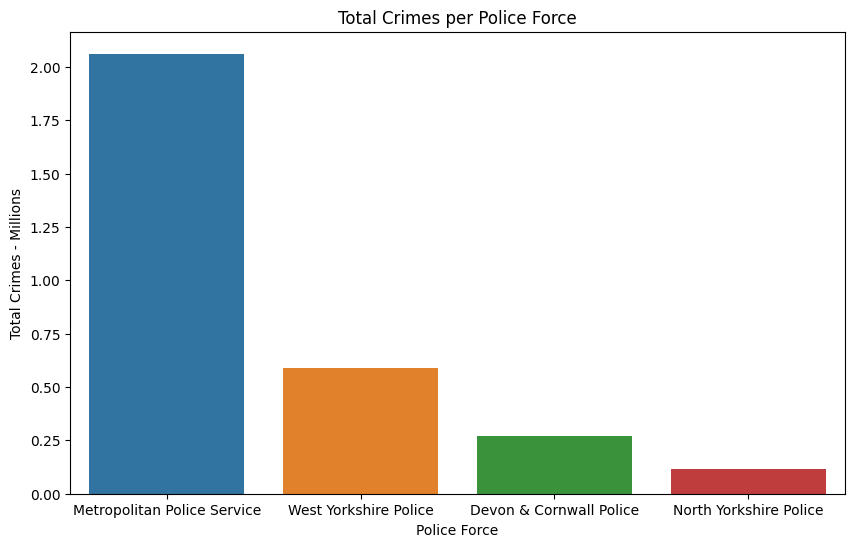

In [3]:
plt.figure(figsize=(10, 6))
crimes_per_force['Total Crimes'] = crimes_per_force['Total Crimes'] / 1000000
sns.barplot(x='Police Force', y='Total Crimes', data=crimes_per_force, hue='Police Force')
plt.title('Total Crimes per Police Force')
plt.xlabel('Police Force')
plt.ylabel('Total Crimes - Millions')
plt.show()

The Metropolitan Police Service recorded over 2 million crimes between 2024 and 2025, significantly higher than the other three forces. West Yorkshire recorded approximately 590,000 crimes, Devon & Cornwall 272,000 and North Yorkshire the lowest with 114,000.

However, these raw figures are influenced by population size. The Metropolitan area covers over 9 million people compared to North Yorkshire's 844,000, meaning a direct comparison is not meaningful. Crime rates per 100,000 population will be explored later in this notebook to provide a fairer comparison between forces.

## 2. Crime Type Distribution

The chart below shows the distribution of crime types as a percentage of total crimes recorded across all 4 police forces.

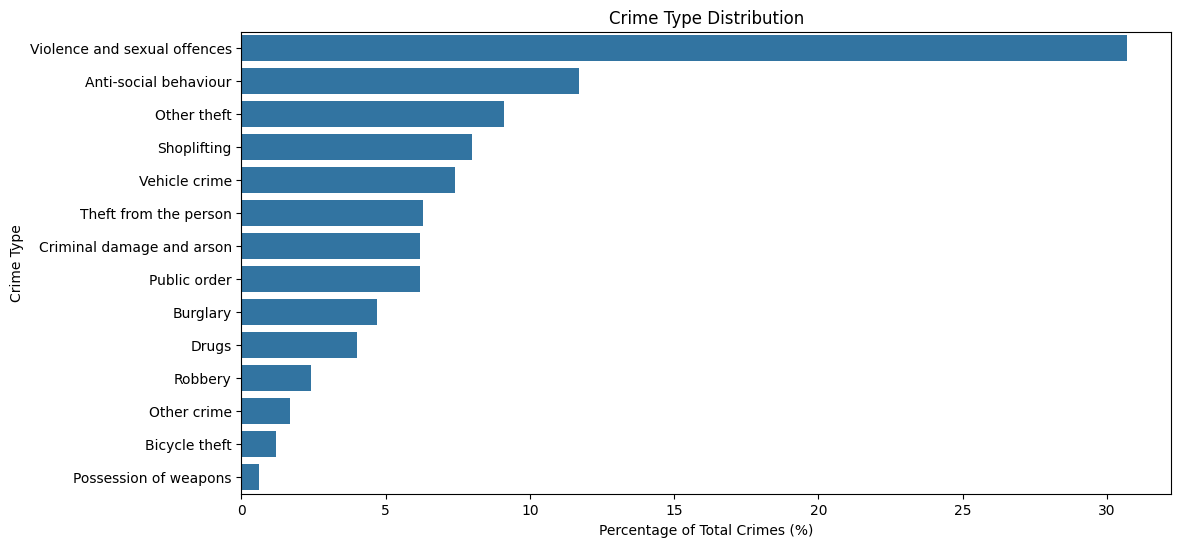

In [4]:
crime_pct = df['Crime type'].value_counts(normalize=True).mul(100).round(1).reset_index()
crime_pct.columns = ['Crime Type', 'Percentage']
plt.figure(figsize=(12, 6))
sns.barplot(y='Crime Type', x='Percentage', data=crime_pct)
plt.title('Crime Type Distribution')
plt.xlabel('Percentage of Total Crimes (%)')
plt.ylabel('Crime Type')
plt.show()

This chart shows the crime type distribution across all 4 police forces combined. Violence and sexual offences accounts for approximately 30% of all recorded crimes, followed by anti-social behaviour at around 12%.

However, these figures are influenced by the Metropolitan Police Service which accounts for the largest share of total crimes. This means that patterns may differ when looking closer into each specifc region. The next chart breaks this down by individual force to give a fairer comparison.

## 2.1 Crime Type Distribution - Regional

The chart below focuses on the top 5 crime types broken down by individual police force.

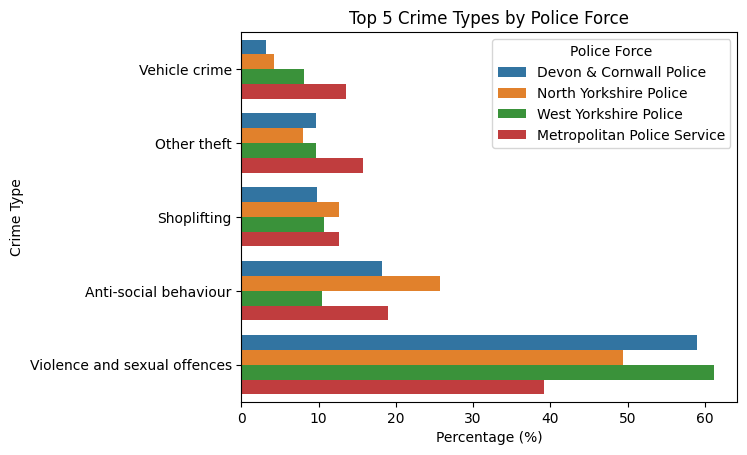

In [5]:
top5 = df['Crime type'].value_counts().head(5).index
crime_force = df[df['Crime type'].isin(top5)].groupby(['Police Force', 'Crime type']).size().reset_index(name='Count')
total = crime_force.groupby('Police Force')['Count'].sum().reset_index()
total.columns = ['Police Force', 'Total']
crime_force = crime_force.merge(total, on='Police Force')
crime_force['Percentage'] = crime_force['Count'] / crime_force['Total'] * 100

sns.barplot(y='Crime type', x='Percentage', data=crime_force.sort_values('Percentage'), hue='Police Force')
plt.title('Top 5 Crime Types by Police Force')
plt.ylabel('Crime Type')
plt.xlabel('Percentage (%)')
plt.show()

When broken down by force the pattern is broadly consistent across all 4 forces. Violence and sexual offences remains the most prevalent crime type in every force. North Yorkshire shows a higher proportion of anti-social behaviour whilst the Metropolitan Police has higher vehicle crime and other theft, typical of a dense urban environment.

## 3. Crime Rate per 100,000 Population

The chart below shows the crime rate per 100,000 population for each police force, providing a fairer comparison than raw crime counts.

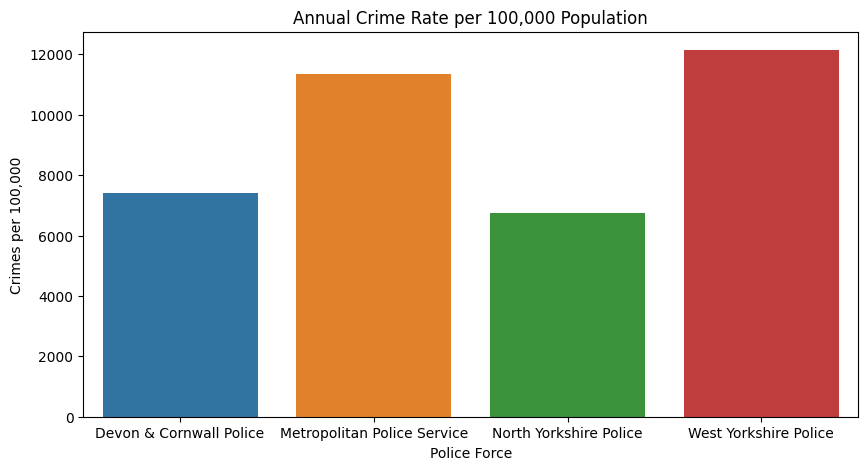

In [6]:
crimes_per_force = df.groupby('Police Force').size().reset_index(name='Total Crimes')
population = df.groupby('Police Force')['Population_2024'].first().reset_index()
crimes_per_force = crimes_per_force.merge(population, on='Police Force')
crimes_per_force['Crime Rate'] = (crimes_per_force['Total Crimes'] / 24 * 12) / crimes_per_force['Population_2024'] * 100000

plt.figure(figsize=(10, 5))
sns.barplot(x='Police Force', y='Crime Rate', data=crimes_per_force, hue='Police Force')
plt.title('Annual Crime Rate per 100,000 Population')
plt.ylabel('Crimes per 100,000')
plt.show()


West Yorkshire has the highest crime rate per 100,000 people, followed by Metropolitan. West Yorkshire has the highest annual crime rate at approximately 12,000 per 100,000 people — meaning roughly 12 crimes recorded per 100 residents per year. Both rural forces Devon & Cornwall and North Yorkshire are noticeably lower. This suggests urban areas have significantly higher crime rates even when accounting for population size.This could be because urban areas such as London and Leeds have higher population density and greater inequality between different areas. All these factors are know nto contribute to higher crime. Rural police forces like North Yorkshire have less people in concentrated areas making certain crime types like theft, violence and anti social behaviour less prominent. 

## 4. Time Series Analysis

The chart below shows the monthly crime rate per 100,000 population for each police force from January 2024 to December 2025. This allows us to identify trends and seasonal patterns over time.

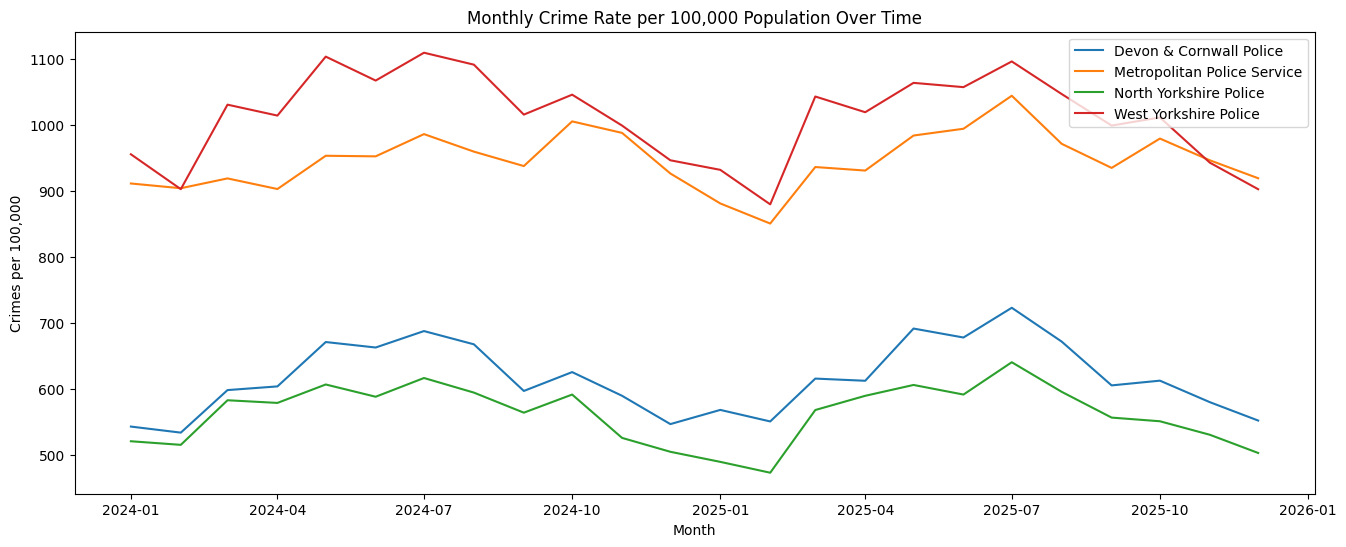

In [7]:
df['Month'] = pd.to_datetime(df['Month'])
monthly = df.groupby(['Month', 'Police Force', 'Population_2024']).size().reset_index(name='Crimes')
monthly['Crime Rate'] = monthly['Crimes'] / monthly['Population_2024'] * 100000

plt.figure(figsize=(16, 6))
sns.lineplot(x='Month', y='Crime Rate', data=monthly, hue='Police Force')
plt.title('Monthly Crime Rate per 100,000 Population Over Time')
plt.xlabel('Month')
plt.ylabel('Crimes per 100,000')
plt.legend(loc='upper right')
plt.show()

There is a clear urban vs rural divide as seen clearly over the 2 year period. Crime spikes in the summer months for all 4 police forces and dips in the winter with West Yorkshire consistently the highest throughout. This could be due to increased activity throughout the summer, increasing crime in all areas.

## 5. Crime Rate vs Median House Price

The chart below compares the annual crime rate per 100,000 population against median house prices across all 4 police forces.

In [8]:
# Median house prices per police force
house_prices_table = df.groupby('Police Force')['Median House Price'].first().reset_index()
house_prices_table

,Police Force,Median House Price
0,Devon & Cornwall Police,280000
1,Metropolitan Police Service,505000
2,North Yorkshire Police,240000
3,West Yorkshire Police,200000


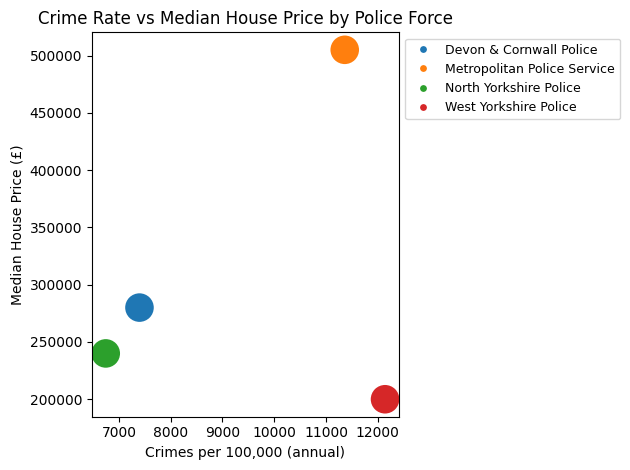

In [9]:
#Group total crimes, population and median house price by police force
house_crime = df.groupby('Police Force').size().reset_index(name='Total Crimes')
population = df.groupby('Police Force')['Population_2024'].first().reset_index()
house_prices = df.groupby('Police Force')['Median House Price'].first().reset_index()

# Calculate annual crime rate per 100,000 population across the 24 month period
house_crime = house_crime.merge(population, on='Police Force')
house_crime = house_crime.merge(house_prices, on='Police Force')
house_crime['Crime Rate'] = (house_crime['Total Crimes'] / 24 * 12) / house_crime['Population_2024'] * 100000

# Graph which explores whether higher crime rates correlate with lower house prices
sns.scatterplot(x='Crime Rate', y='Median House Price', data=house_crime, hue='Police Force', s=500)
plt.title('Crime Rate vs Median House Price by Police Force')
plt.xlabel('Crimes per 100,000 (annual)')
plt.ylabel('Median House Price (£)')
plt.legend(bbox_to_anchor=(1, 1), markerscale=0.3, fontsize=9)
plt.tight_layout()
plt.show()

Metropolitan has the highest house prices at £505,000 despite having a high crime rate which suggests high demand in that urban area. West Yorkshire also has a high crime rate but has the lowest house prices at £200,000 showcasing that not all urban areas are high in demand.  The two rural police forces Devon & Cornwall and North Yorkshire have lower crime rates and mid range house prices.

## 6. Crime Outcomes by Force

The heatmap shows the top 5 outcome categories which account for over 85% of all recorded crime outcomes across all 4 forces.

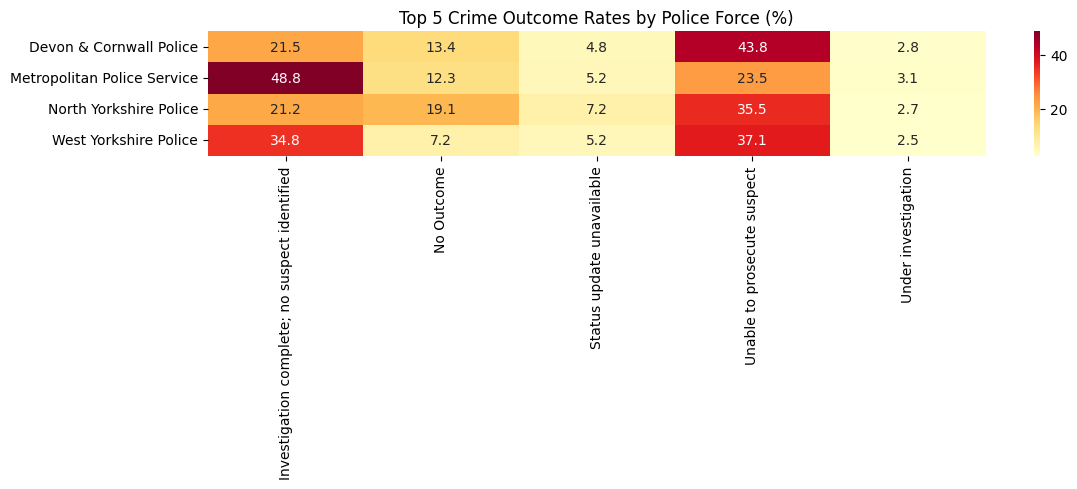

In [10]:
# Calculate outcome percentages per police force
outcomes = df.groupby(['Police Force', 'Last outcome category']).size().reset_index(name='Count')
total = outcomes.groupby('Police Force')['Count'].sum().reset_index(name='Total')
outcomes = outcomes.merge(total, on='Police Force')
outcomes['Percentage'] = outcomes['Count'] / outcomes['Total'] * 100

# Filter to top 5 most common outcomes as they take up majority of %
top_outcomes = df['Last outcome category'].value_counts().head(5).index
outcomes = outcomes[outcomes['Last outcome category'].isin(top_outcomes)]
outcomes_pivot = outcomes.pivot_table(index='Police Force', columns='Last outcome category', values='Percentage')

# Visualise the graph to show outcome rates via a heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(outcomes_pivot, cmap='YlOrRd', annot=True, fmt='.1f')
plt.title('Top 5 Crime Outcome Rates by Police Force (%)')
plt.xlabel(''), plt.ylabel('')
plt.tight_layout()
plt.show()

The urban areas in Metropilitan and west yorkshire police forces have the highest investigations completed with no suspects found which suggests perpetrators often get away with their crimes. Rural areas such as North Yorkshire and Devon have lower levels of suspects not being found with more of the crime outcomes being unable to prosecute the suspect.

## 7. Crime Density Map - Overview

The map below shows the geographic concentration of crime across all 4 police force areas using a hexbin density map.

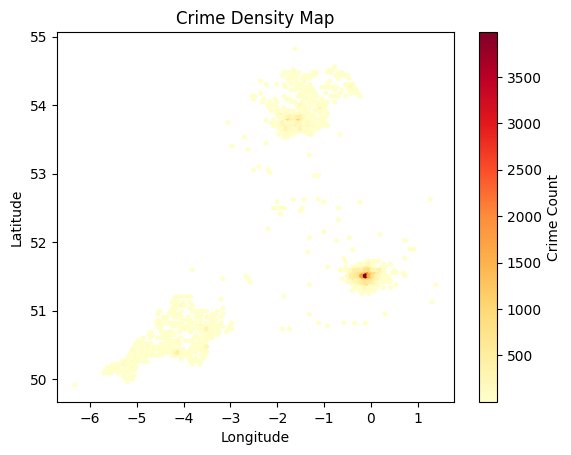

In [11]:
# Use a sample size of 50,000 records to keep graph accurate and have enough data for informed decisions.
df_sample = df.sample(n=50000, random_state=42)

# Hexbin density map to show geographic concentration of crime across all 4 force areas
plt.hexbin(df_sample['Longitude'], df_sample['Latitude'], gridsize=100, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Crime Count')
plt.title('Crime Density Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

London shows the highest crime concentration whilst Devon & Cornwall and North and West Yorkshire are more spread out across the geographical area. Crime concentration is a lot higher in London. 

## 7.1 Crime Density Map - Metropolitan Police

The map below shows where crime is most concentrated across the Metropolitan Police area.

Approximate geographic coordinates for the Metropolitan Police Service were identified using OpenStreetMap and used to set the map boundaries for the density visualisations. This source is referenced and cited in the EDA report.

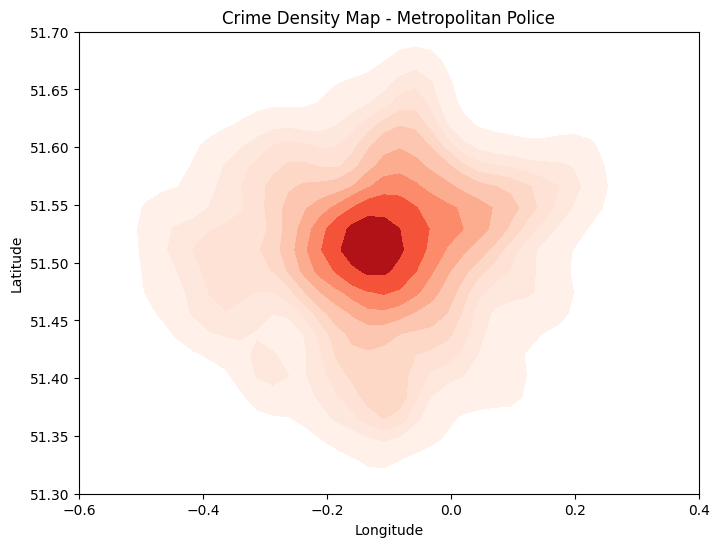

In [12]:
df_metro = df[df['Police Force'] == 'Metropolitan Police Service']
#10,000 sample to not break computer and make slow

df_metro_sample = df_metro.sample(n=10000, random_state=42)

plt.figure(figsize=(8, 6))
sns.kdeplot(x=df_metro_sample['Longitude'], y=df_metro_sample['Latitude'],cmap='Reds', fill=True, thresh=0.05)
plt.title('Crime Density Map - Metropolitan Police')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#Crops the view to London so outlier points outside the area are not visible
plt.xlim(-0.6, 0.4)
plt.ylim(51.3, 51.7)
plt.show()

Crime is heavily concentrated in Central London with density reducing significantly towards the outer boroughs. This suggests outer London offers safer areas for investment whilst still benefiting from London house price premiums.

## 7.2 Crime Density Map - West Yorkshire Police

The map below shows where crime is most concentrated across the West Yorkshire Police area.

Approximate geographic coordinates for West Yorkshire Police were identified using OpenStreetMap and used to set the map boundaries for the density visualisations. This source is referenced and cited in the EDA report.

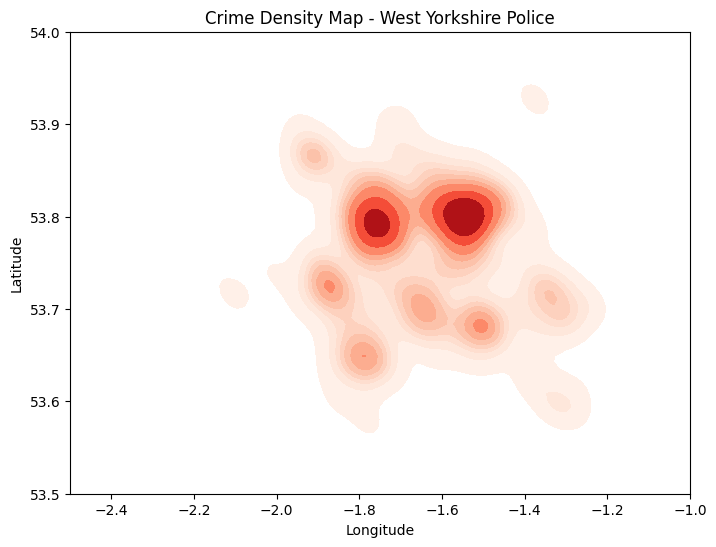

In [ ]:
# Filter to West Yorkshire only
df_westyork = df[df['Police Force'] == 'West Yorkshire Police']
#Sample of 10,000 to not break computer and make slow
df_westyork_sample = df_westyork.sample(n=10000, random_state=42)

plt.figure(figsize=(8, 6))
sns.kdeplot(x=df_westyork_sample['Longitude'], y=df_westyork_sample['Latitude'], cmap='Reds', fill=True, thresh=0.05)
plt.title('Crime Density Map - West Yorkshire Police')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#Crops the view to West Yorkshire so outlier points outside the area are not visible
plt.xlim(-2.5, -1.0)
plt.ylim(53.5, 54.0)
plt.show()

West Yorkshire has 2 clear density hotspots which are Leeds and Bradford. Crime is spread across multiple cities rather than focussed on one single spot making crime harder to avoid. 

## 7.3 Crime Density Map - Devon & Cornwall Police

The map below shows where crime is most concentrated across the Devon and Cornwall Police area.

Approximate geographic coordinates for Devon and Cornwall Police were identified using OpenStreetMap and used to set the map boundaries for the density visualisations. This source is referenced and cited in the EDA report.

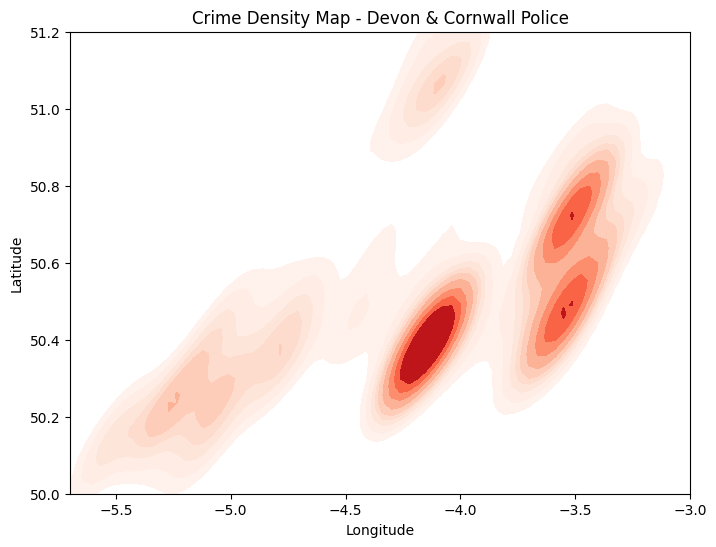

In [ ]:
# Filter to Devon & Cornwall only
df_devon = df[df['Police Force'] == 'Devon & Cornwall Police']

# Sample 10000 rows to speed up plotting enough size for graph
df_devon_sample = df_devon.sample(n=10000, random_state=42)

plt.figure(figsize=(8, 6))
sns.kdeplot(x=df_devon_sample['Longitude'], y=df_devon_sample['Latitude'], cmap='Reds', fill=True, thresh=0.13)
plt.title('Crime Density Map - Devon & Cornwall Police')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#Crops the view to Devon & Cornwall so outlier points outside the area are not visible
plt.xlim(-5.7, -3.0)
plt.ylim(50.0, 51.2)
plt.show()

Crime in Devon and Cornwall is spread across smaller hotspots rather than one concentration. The main areas are Plymouth and Exeter which are the largest urban centres in the region. 

## 7.4 Crime Density Map - North Yorkshire Police

The map below shows where crime is most concentrated across the North Yorkshire Police area.

Approximate geographic coordinates for North Yorkshire Police were identified using OpenStreetMap and used to set the map boundaries for the density visualisations. This source is referenced and cited in the EDA report.

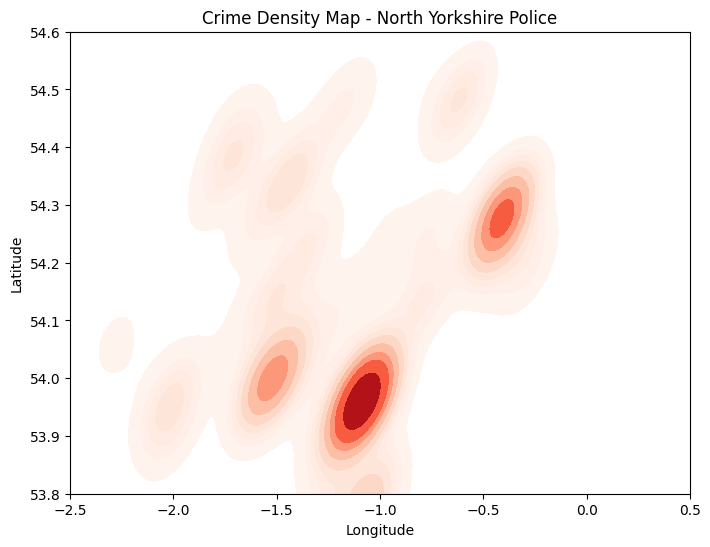

In [ ]:
# Filter to North Yorkshire only
df_northyork = df[df['Police Force'] == 'North Yorkshire Police']

# Sample 10000 rows to speed up plotting enough size for graph
df_northyork_sample = df_northyork.sample(n=10000, random_state=42)

plt.figure(figsize=(8, 6))
sns.kdeplot(x=df_northyork_sample['Longitude'], y=df_northyork_sample['Latitude'], cmap='Reds', fill=True, thresh=0.05)
plt.title('Crime Density Map - North Yorkshire Police')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#Crops the view to North Yorkshire so outlier points outside the area are not visible
plt.xlim(-2.5, 0.5)
plt.ylim(53.8, 54.6)
plt.show()

North Yorkshire has a fewer small scattered crime hotspots rather than one major concentration. This pattern reflects it being a rural region with overall crime levels much lower than the ones in urban police forces.